In [1]:
import sys
from pathlib import Path
import torch
import numpy as np

script_dir = Path.cwd()
sys.path.insert(0, str(script_dir.parent.parent))

from config import PROJECT_ROOT, XLSR_DROPOUT
from model import AD_XLSR_Model
from dataset import create_dataloaders, FeatureDataset
from train import validate
from train_ST import train_st
from visualization import plot_training_curves, plot_dataset_comparison

2026-01-16 12:11:35 | INFO | fairseq.tasks.text_to_speech | Please install tensorboardX: pip install tensorboardX


In [2]:
SOURCE_DATASET = "ADReSS"
TARGET_DATASET = "Lu"

# Model Selection Weights and Thresholds
SOURCE_WEIGHT = 0.5  # Weight for source domain validation accuracy
TARGET_WEIGHT = 0.5  # Weight for target domain validation accuracy

# Self-Training Hyperparameters
ST_WARMUP_EPOCHS = 20           # Number of epochs to train on source domain before applying ST (iteration 0)
ST_MAX_EPOCHS = 60              # Number of epochs for each ST iteration (iteration 1+)
CONFIDENCE_THRESHOLD = 0.9
MAX_ITERATIONS = 5
MIN_PSEUDO_SAMPLES = 5

# Class weights for handling imbalance (None = auto-compute dynamically)
CLASS_WEIGHT_CONTROL = None
CLASS_WEIGHT_DEMENTIA = None

# Device setup
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Device: {device}")

Device: cuda


In [3]:
# ============= Feature Extraction Configuration =============
# Set to True to extract features using finetuned XLSR
# After extraction is complete, set to False to skip re-extraction
EXTRACT_FEATURES = True  

# Feature extraction settings
USE_FINETUNED_XLSR = True  # True: use finetuned XLSR, False: use original
FINETUNED_MODEL_PATH = f"/root/autodl-tmp/data/{SOURCE_DATASET}-finetuned-xlsr.pth"
RAW_AUDIO_DIR = Path(f"/root/autodl-tmp/data/raw/{SOURCE_DATASET}")

# Output configuration
if USE_FINETUNED_XLSR:
    FEATURE_DIR_NAME = f"{SOURCE_DATASET}_xlsr_finetuned_features"
    CSV_SUFFIX = "finetuned"
else:
    FEATURE_DIR_NAME = f"{SOURCE_DATASET}_xlsr_features"
    CSV_SUFFIX = ""

In [4]:
# ============= Execute Feature Extraction =============
from extract_XLSR_feature import extract_features_from_csv
from model import SSLModel
import csv

# Step 1: Initialize SSLModel with optional finetuned weights
ssl_model = SSLModel(
    device=device,
    freeze_xlsr=True,
    finetuned_model_path=FINETUNED_MODEL_PATH if USE_FINETUNED_XLSR else None
)

data_dir = PROJECT_ROOT / "data" / "processed"
train_csv_path = data_dir / f"{SOURCE_DATASET}-xlsr-train.csv"
val_csv_path = data_dir / f"{SOURCE_DATASET}-xlsr-val.csv"
xlsr_features_dir = data_dir / FEATURE_DIR_NAME

# Step 3: Extract features for train and val sets
for split_name, csv_path in [("train", train_csv_path), ("val", val_csv_path)]:
    extract_features_from_csv(
        csv_path=csv_path,
        split_name=f"{SOURCE_DATASET}-{split_name}",
        raw_audio_dir=RAW_AUDIO_DIR,
        xlsr_features_dir=xlsr_features_dir,
        device=device,
        ssl_model=ssl_model,  # Pass the initialized model
        freeze_xlsr=True
    )

# Step 4: Update CSV files to point to new features
for csv_file in [train_csv_path, val_csv_path]:
    # Read CSV
    with open(csv_file, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        rows = list(reader)
    
    # Update xlsr_path column
    for row in rows:
        session_id = row['session_id']
        row['xlsr_path'] = f"{FEATURE_DIR_NAME}/{session_id}.xlsr.pt"
    
    # Write back CSV
    with open(csv_file, 'w', encoding='utf-8', newline='') as f:
        fieldnames = ['session_id', 'xlsr_path', 'ad']
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


XLSR: Loading base model structure


/root/miniconda3/envs/xlsr_env/lib/python3.9/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


XLSR: Loading finetuned weights from /root/autodl-tmp/data/ADReSS-finetuned-xlsr.pth
XLSR: ✓ Loaded finetuned model from epoch 29
XLSR: ✓ Best validation accuracy: 84.38%

============= Extracting XLSR features for ADReSS-train =============
124 Audio Files


Extracting ADReSS-train:   0%|          | 0/124 [00:00<?, ?it/s]

Successfully extracted: 0
Already exists (skipped): 124
Errors: 0
Total: 124

============= Extracting XLSR features for ADReSS-val =============
32 Audio Files


Extracting ADReSS-val:   0%|          | 0/32 [00:00<?, ?it/s]

Successfully extracted: 0
Already exists (skipped): 32
Errors: 0
Total: 32


In [5]:
data_dir = PROJECT_ROOT / "data" / "processed"

SOURCE_TRAIN_CSV = data_dir / f"{SOURCE_DATASET}-xlsr-train.csv"
SOURCE_VAL_CSV = data_dir / f"{SOURCE_DATASET}-xlsr-val.csv"
TARGET_TRAIN_CSV = data_dir / f"{TARGET_DATASET}-xlsr-train.csv"
TARGET_VAL_CSV = data_dir / f"{TARGET_DATASET}-xlsr-val.csv"

MODEL_OUTPUT_DIR = PROJECT_ROOT / "models" / f"ST_{SOURCE_DATASET}_to_{TARGET_DATASET}_xlsr_t{int(CONFIDENCE_THRESHOLD*100)}"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output: {MODEL_OUTPUT_DIR}")

Output: /root/autodl-tmp/models/ST_ADReSS_to_Lu_xlsr_t90


## 1 Load Data

In [6]:
source_train_dataset = FeatureDataset(SOURCE_TRAIN_CSV, xlsr=True)
target_train_dataset = FeatureDataset(TARGET_TRAIN_CSV, xlsr=True)

source_val_loader = create_dataloaders(SOURCE_VAL_CSV, xlsr=True)
target_val_loader = create_dataloaders(TARGET_VAL_CSV, xlsr=True)

Loading completed: 124 samples
Control: 62, Dementia: 62


Loading completed: 58 samples
Control: 28, Dementia: 30


Loading completed: 32 samples
Control: 16, Dementia: 16


Loading completed: 16 samples
Control: 8, Dementia: 8




## 2 Define Evaluation Functions

In [7]:
# Evaluation helper for all seeds
def evaluate_and_visualize_st(seed, all_metrics, all_histories, all_pseudo_stats,
                              source_val_loader, target_val_loader, output_dir, device):
    """Evaluate best ST iteration and visualize source vs target performance."""
    if not all_metrics:
        raise ValueError('all_metrics is empty; run training first.')

    # Pick best iteration by avg_val_acc
    best_iter_idx = max(
        range(len(all_metrics)),
        key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0
    )
    best_metric = all_metrics[best_iter_idx]

    print('='*60)
    print(f"Evaluating Best Model (Seed {seed})")
    print(f"Best Iteration: {best_iter_idx}")
    if best_metric:
        print(f"Best Avg Acc: {best_metric.get('avg_val_acc', 0)*100:.2f}%")
        print(f"  Source: {best_metric.get('source_val_acc', 0)*100:.2f}%")
        print(f"  Target: {best_metric.get('target_val_acc', 0)*100:.2f}%")
    print('='*60)

    model_path = output_dir / f"seed_{seed}" / f"st_iter_{best_iter_idx}.pth"
    print(f"Loading model from: {model_path}")

    best_model = AD_XLSR_Model(dropout=XLSR_DROPOUT).to(device)
    best_model.load_state_dict(torch.load(model_path, map_location=device))

    source_loss, source_acc, source_control_acc, source_dementia_acc, source_f1 = validate(
        best_model, source_val_loader, device
    )
    target_loss, target_acc, target_control_acc, target_dementia_acc, target_f1 = validate(
        best_model, target_val_loader, device
    )

    print(f"\n{'Dataset':<25} {'Accuracy':<12} {'F1 Score':<12} {'Dementia':<12} {'Control':<12} {'Loss':<10}")
    print('-'*85)
    print(f"{f'{SOURCE_DATASET} (source domain)':<25} {source_acc*100:>10.2f}%  {source_f1:>10.4f}  {source_dementia_acc*100:>10.2f}%  {source_control_acc*100:>10.2f}%  {source_loss:>8.4f}")
    print(f"{f'{TARGET_DATASET} (target domain)':<25} {target_acc*100:>10.2f}%  {target_f1:>10.4f}  {target_dementia_acc*100:>10.2f}%  {target_control_acc*100:>10.2f}%  {target_loss:>8.4f}")
    print('-'*85)

    loaded_avg_acc = SOURCE_WEIGHT * source_acc + TARGET_WEIGHT * target_acc
    expected_avg_acc = best_metric.get('avg_val_acc', 0)
    if abs(loaded_avg_acc - expected_avg_acc) > 0.01:
        print("\n⚠️  WARNING: Loaded model accuracy mismatch!")
        print(f"   Expected avg acc: {expected_avg_acc*100:.2f}%")
        print(f"   Actual avg acc:   {loaded_avg_acc*100:.2f}%")
    else:
        print(f"\n✓ Model verification passed (avg acc: {loaded_avg_acc*100:.2f}%)")

    dataset_names = [f'{SOURCE_DATASET} (source)', f'{TARGET_DATASET} (target)']
    accuracies = [source_acc * 100, target_acc * 100]
    plot_dataset_comparison(
        dataset_names=dataset_names,
        accuracies=accuracies,
        title=f'ST Performance (Seed {seed}, Iter {best_iter_idx})',
        custom_colors={
            f'{SOURCE_DATASET} (source)': '#3498db',
            f'{TARGET_DATASET} (target)': '#e74c3c'
        }
    )

    source_metrics = {
        'acc': source_acc, 'f1': source_f1,
        'dementia_acc': source_dementia_acc,
        'control_acc': source_control_acc,
        'loss': source_loss
    }
    target_metrics = {
        'acc': target_acc, 'f1': target_f1,
        'dementia_acc': target_dementia_acc,
        'control_acc': target_control_acc,
        'loss': target_loss
    }
    return source_metrics, target_metrics


## 3 Training with Multiple Seeds

In [8]:
all_results = {
    'seeds': [],
    'metrics': [],
    'histories': [],
    'pseudo_stats': [],
    'source_metrics': [],
    'target_metrics': []
}

### Seed 21


Self-Training: Seed 21
Model Selection: Avg Acc (Source 0.5, Target 0.5)
Confidence Threshold: 0.9
Max Iterations: 5

Iteration 0: Initial training on source domain only

ST Iteration 0 - Training
Model Selection: Avg Acc (Source 0.5, Target 0.5)


Epoch   1 | Train: 0.468 | Source Val: 0.438 | Target Val: 0.250 | Avg: 0.344


Epoch   2 | Train: 0.661 | Source Val: 0.594 | Target Val: 0.438 | Avg: 0.516


Epoch   3 | Train: 0.806 | Source Val: 0.625 | Target Val: 0.375 | Avg: 0.500


Epoch   4 | Train: 0.887 | Source Val: 0.688 | Target Val: 0.375 | Avg: 0.531


...

Epoch  11 | Train: 0.949 | Source Val: 0.688 | Target Val: 0.688 | Avg: 0.688


Epoch  12 | Train: 0.994 | Source Val: 0.750 | Target Val: 0.750 | Avg: 0.750


Epoch  13 | Train: 0.987 | Source Val: 0.750 | Target Val: 0.688 | Avg: 0.719


Epoch  14 | Train: 0.968 | Source Val: 0.719 | Target Val: 0.812 | Avg: 0.766


Epoch  15 | Train: 0.955 | Source Val: 0.750 | Target Val: 0.750 | Avg: 0.750
Early stopping at epoch 15 (best epoch: 5)

Iteration 5 Best Results (Epoch 5):
  Avg Acc: 76.56%
  Source Acc: 78.12% | F1: 0.7586
  Target Acc: 75.00% | F1: 0.7500

Self-Training Summary (Seed 21)
Best iteration: 4
Best avg accuracy: 82.81%

Per-Iteration Results:
Iter   Avg Acc      Source Acc   Target Acc   Source F1    Target F1    Pseudo    
--------------------------------------------------------------------------------
0           75.00%      68.75%      81.25%     0.7222     0.8235        0
1           78.12%      75.00%      81.25%     0.6923     0.8235       35
2           81.25%      75.00%      87.50%     0.7778     0.8750       47
3           79.69%      78.12%      81.25%     0.7879     0.8235       41
4           82.81%      78.12%      87.50%     0.7742     0.8750       38
5           76.56%      78.12%      75.00%     0.7586     0.7500       32


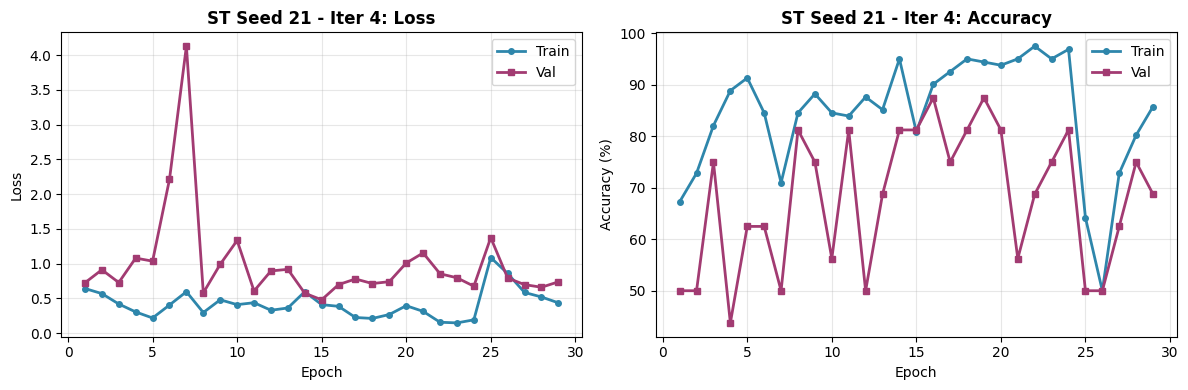

Evaluating Best Model (Seed 21)
Best Iteration: 4
Best Avg Acc: 82.81%
  Source: 78.12%
  Target: 87.50%
Loading model from: /root/autodl-tmp/models/ST_ADReSS_to_Lu_xlsr_t90/seed_21/st_iter_4.pth



Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
ADReSS (source domain)         78.12%      0.7742       75.00%       81.25%    0.5688
Lu (target domain)             87.50%      0.8750       87.50%       87.50%    0.7394
-------------------------------------------------------------------------------------

✓ Model verification passed (avg acc: 82.81%)


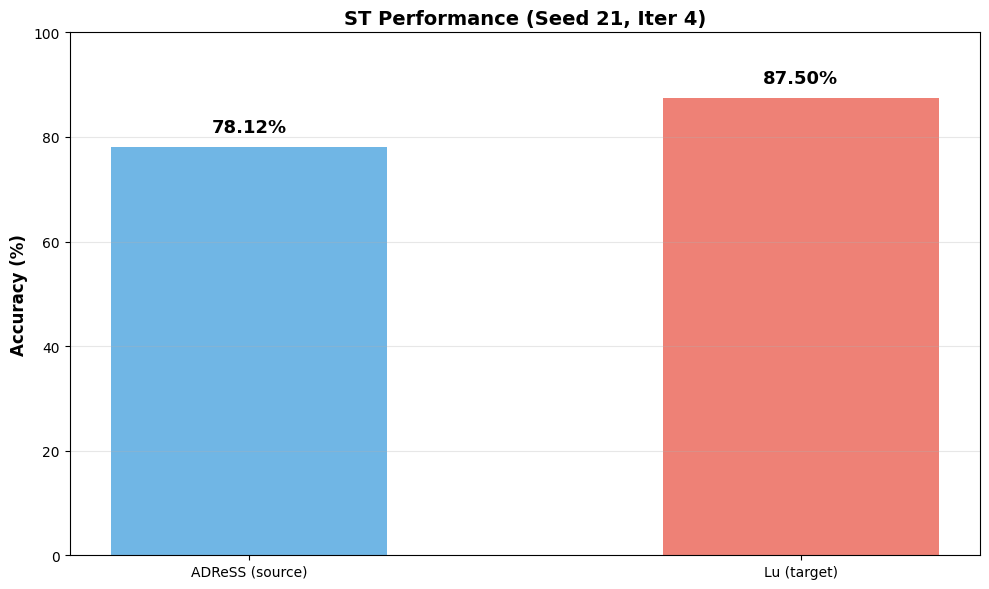

In [9]:
seed, all_metrics, all_histories, all_pseudo_stats = train_st(
    seed=21,
    source_train_dataset=source_train_dataset,
    target_train_dataset=target_train_dataset,
    source_val_loader=source_val_loader,
    target_val_loader=target_val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device,
    max_iterations=MAX_ITERATIONS,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    min_pseudo_samples=MIN_PSEUDO_SAMPLES,
    manual_weight_control=CLASS_WEIGHT_CONTROL,
    manual_weight_dementia=CLASS_WEIGHT_DEMENTIA,
    warmup_epochs=ST_WARMUP_EPOCHS,
    max_epochs=ST_MAX_EPOCHS,
    source_weight=SOURCE_WEIGHT,
    target_weight=TARGET_WEIGHT,
)

all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)

# Find best iteration and plot its training curves
best_iter_idx = max(range(len(all_metrics)), key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0)
best_history = all_histories[best_iter_idx]

plot_training_curves(
    epochs=best_history['epochs'],
    train_loss=best_history['train_losses'],
    val_loss=best_history['target_val_losses'],
    train_acc=best_history['train_accs'],
    val_acc=best_history['target_val_accs'],
    title_prefix=f'ST Seed {seed} - Iter {best_iter_idx}'
)

# Evaluate best model (function will load correct iteration checkpoint)
source_metrics, target_metrics = evaluate_and_visualize_st(
    seed, all_metrics, all_histories, all_pseudo_stats,
    source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device
)

all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

### Seed 42


Self-Training: Seed 42
Model Selection: Avg Acc (Source 0.5, Target 0.5)
Confidence Threshold: 0.9
Max Iterations: 5

Iteration 0: Initial training on source domain only

ST Iteration 0 - Training
Model Selection: Avg Acc (Source 0.5, Target 0.5)


Epoch   1 | Train: 0.532 | Source Val: 0.500 | Target Val: 0.500 | Avg: 0.500


Epoch   2 | Train: 0.774 | Source Val: 0.625 | Target Val: 0.438 | Avg: 0.531


Epoch   3 | Train: 0.887 | Source Val: 0.656 | Target Val: 0.438 | Avg: 0.547


Epoch   4 | Train: 0.919 | Source Val: 0.688 | Target Val: 0.375 | Avg: 0.531


...

Epoch  12 | Train: 0.976 | Source Val: 0.656 | Target Val: 0.812 | Avg: 0.734


Epoch  13 | Train: 0.965 | Source Val: 0.719 | Target Val: 0.812 | Avg: 0.766


Epoch  14 | Train: 0.953 | Source Val: 0.719 | Target Val: 0.812 | Avg: 0.766


Epoch  15 | Train: 0.947 | Source Val: 0.688 | Target Val: 0.812 | Avg: 0.750


Epoch  16 | Train: 0.976 | Source Val: 0.750 | Target Val: 0.750 | Avg: 0.750
Early stopping at epoch 16 (best epoch: 6)

Iteration 5 Best Results (Epoch 6):
  Avg Acc: 78.12%
  Source Acc: 81.25% | F1: 0.8235
  Target Acc: 75.00% | F1: 0.7500

Self-Training Summary (Seed 42)
Best iteration: 2
Best avg accuracy: 79.69%

Per-Iteration Results:
Iter   Avg Acc      Source Acc   Target Acc   Source F1    Target F1    Pseudo    
--------------------------------------------------------------------------------
0           62.50%      75.00%      50.00%     0.7778     0.3333        0
1           75.00%      68.75%      81.25%     0.7368     0.8235       27
2           79.69%      78.12%      81.25%     0.7879     0.8000       38
3           79.69%      78.12%      81.25%     0.7879     0.8235       44
4           79.69%      78.12%      81.25%     0.7742     0.8000       46
5           78.12%      81.25%      75.00%     0.8235     0.7500       46


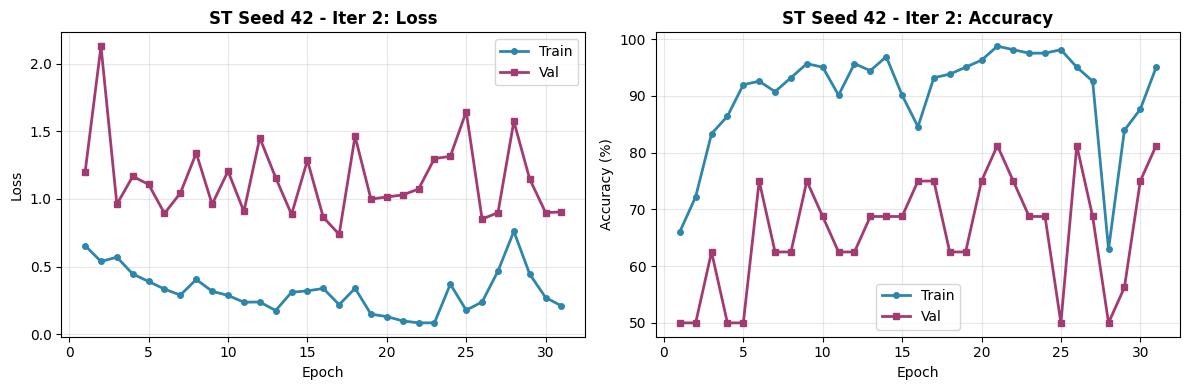

Evaluating Best Model (Seed 42)
Best Iteration: 2
Best Avg Acc: 79.69%
  Source: 78.12%
  Target: 81.25%
Loading model from: /root/autodl-tmp/models/ST_ADReSS_to_Lu_xlsr_t90/seed_42/st_iter_2.pth



Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
ADReSS (source domain)         78.12%      0.7879       81.25%       75.00%    0.6748
Lu (target domain)             81.25%      0.8000       75.00%       87.50%    1.0296
-------------------------------------------------------------------------------------

✓ Model verification passed (avg acc: 79.69%)


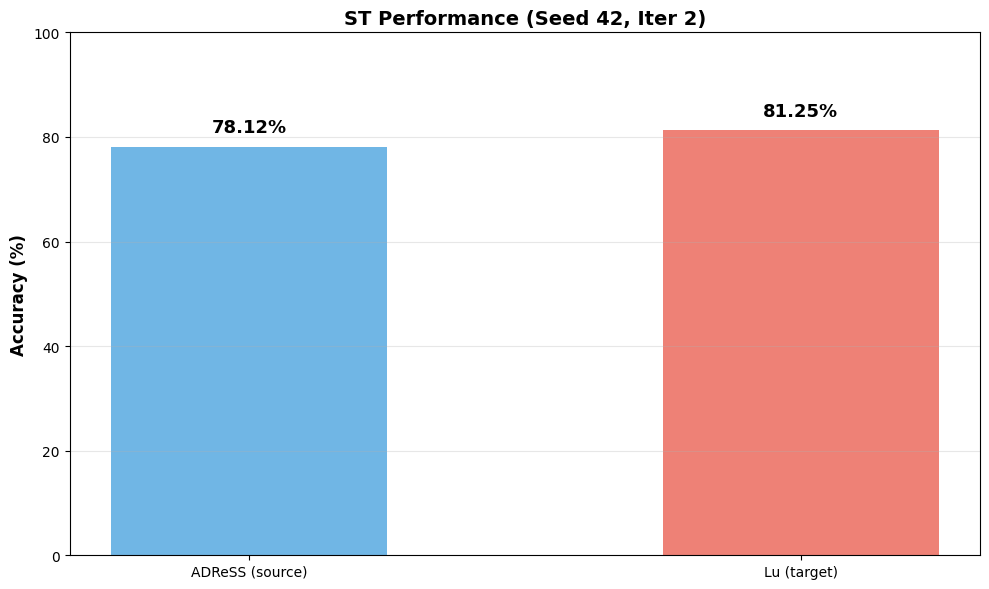

In [10]:
seed, all_metrics, all_histories, all_pseudo_stats = train_st(
    42, source_train_dataset, target_train_dataset, source_val_loader, target_val_loader,
    MODEL_OUTPUT_DIR, device, MAX_ITERATIONS, CONFIDENCE_THRESHOLD, MIN_PSEUDO_SAMPLES,
    CLASS_WEIGHT_CONTROL, CLASS_WEIGHT_DEMENTIA, ST_WARMUP_EPOCHS, ST_MAX_EPOCHS,
)
all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)

best_iter_idx = max(range(len(all_metrics)), key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0)
plot_training_curves(all_histories[best_iter_idx]['epochs'], all_histories[best_iter_idx]['train_losses'],
                     all_histories[best_iter_idx]['target_val_losses'], all_histories[best_iter_idx]['train_accs'],
                     all_histories[best_iter_idx]['target_val_accs'], title_prefix=f'ST Seed {seed} - Iter {best_iter_idx}')

source_metrics, target_metrics = evaluate_and_visualize_st(seed, all_metrics, all_histories, all_pseudo_stats,
                                                            source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

### Seed 84


Self-Training: Seed 84
Model Selection: Avg Acc (Source 0.5, Target 0.5)
Confidence Threshold: 0.9
Max Iterations: 5

Iteration 0: Initial training on source domain only

ST Iteration 0 - Training
Model Selection: Avg Acc (Source 0.5, Target 0.5)


Epoch   1 | Train: 0.540 | Source Val: 0.469 | Target Val: 0.500 | Avg: 0.484


Epoch   2 | Train: 0.750 | Source Val: 0.625 | Target Val: 0.250 | Avg: 0.438


Epoch   3 | Train: 0.847 | Source Val: 0.750 | Target Val: 0.375 | Avg: 0.562


Epoch   4 | Train: 0.927 | Source Val: 0.656 | Target Val: 0.375 | Avg: 0.516


...

Epoch  22 | Train: 0.811 | Source Val: 0.719 | Target Val: 0.562 | Avg: 0.641


Epoch  23 | Train: 0.789 | Source Val: 0.656 | Target Val: 0.750 | Avg: 0.703


Epoch  24 | Train: 0.857 | Source Val: 0.656 | Target Val: 0.688 | Avg: 0.672


Epoch  25 | Train: 0.909 | Source Val: 0.812 | Target Val: 0.750 | Avg: 0.781


Epoch  26 | Train: 0.983 | Source Val: 0.688 | Target Val: 0.750 | Avg: 0.719
Early stopping at epoch 26 (best epoch: 16)

Iteration 5 Best Results (Epoch 16):
  Avg Acc: 78.12%
  Source Acc: 68.75% | F1: 0.7500
  Target Acc: 87.50% | F1: 0.8750

Self-Training Summary (Seed 84)
Best iteration: 2
Best avg accuracy: 82.81%

Per-Iteration Results:
Iter   Avg Acc      Source Acc   Target Acc   Source F1    Target F1    Pseudo    
--------------------------------------------------------------------------------
0           70.31%      84.38%      56.25%     0.8571     0.4615        0
1           76.56%      78.12%      75.00%     0.7879     0.7778       35
2           82.81%      84.38%      81.25%     0.8387     0.8235       53
3           82.81%      84.38%      81.25%     0.8485     0.8235       49
4           79.69%      78.12%      81.25%     0.7407     0.8000       48
5           78.12%      68.75%      87.50%     0.7500     0.8750       51


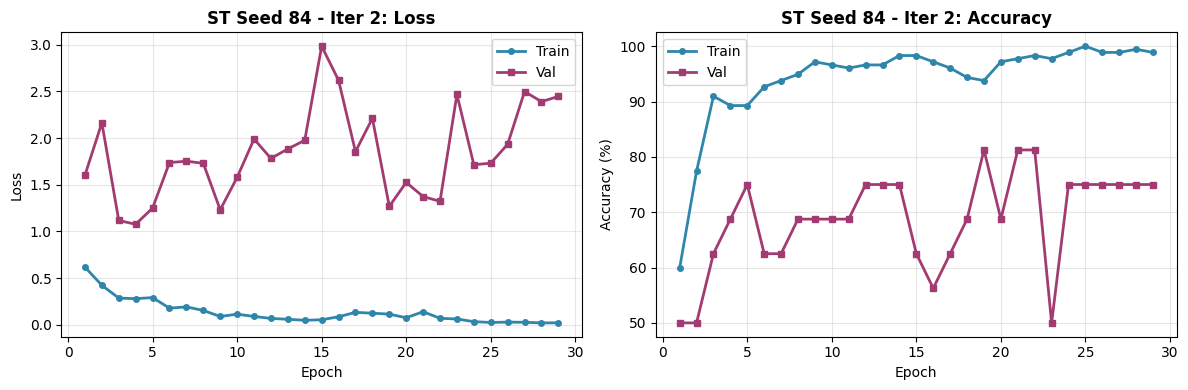

Evaluating Best Model (Seed 84)
Best Iteration: 2
Best Avg Acc: 82.81%
  Source: 84.38%
  Target: 81.25%
Loading model from: /root/autodl-tmp/models/ST_ADReSS_to_Lu_xlsr_t90/seed_84/st_iter_2.pth



Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
ADReSS (source domain)         84.38%      0.8387       81.25%       87.50%    0.5769
Lu (target domain)             81.25%      0.8235       87.50%       75.00%    1.2689
-------------------------------------------------------------------------------------

✓ Model verification passed (avg acc: 82.81%)


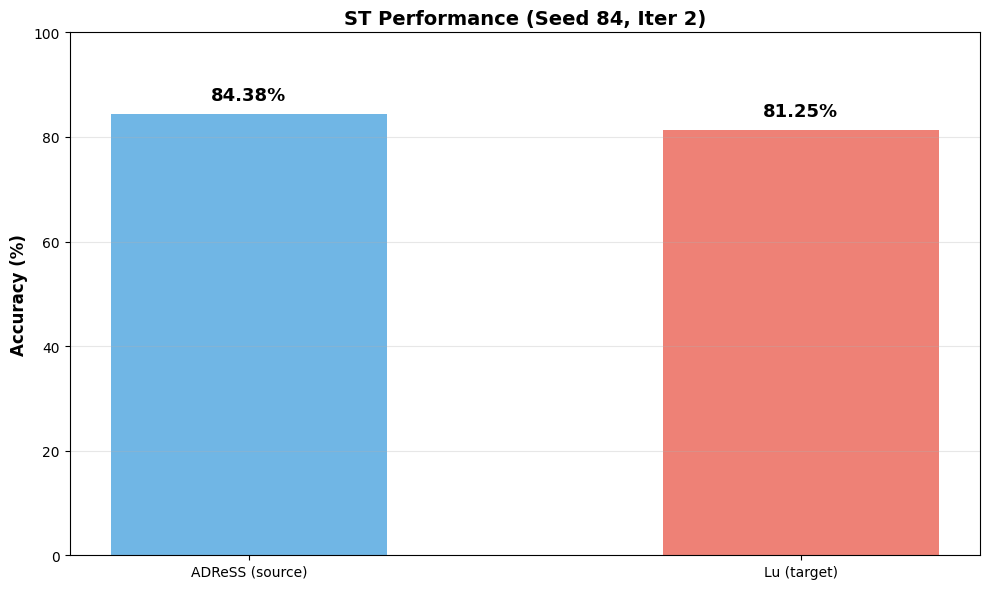

In [11]:
seed, all_metrics, all_histories, all_pseudo_stats = train_st(
    84, source_train_dataset, target_train_dataset, source_val_loader, target_val_loader,
    MODEL_OUTPUT_DIR, device, MAX_ITERATIONS, CONFIDENCE_THRESHOLD, MIN_PSEUDO_SAMPLES,
    CLASS_WEIGHT_CONTROL, CLASS_WEIGHT_DEMENTIA, ST_WARMUP_EPOCHS, ST_MAX_EPOCHS,
)
all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)

best_iter_idx = max(range(len(all_metrics)), key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0)
plot_training_curves(all_histories[best_iter_idx]['epochs'], all_histories[best_iter_idx]['train_losses'],
                     all_histories[best_iter_idx]['target_val_losses'], all_histories[best_iter_idx]['train_accs'],
                     all_histories[best_iter_idx]['target_val_accs'], title_prefix=f'ST Seed {seed} - Iter {best_iter_idx}')

source_metrics, target_metrics = evaluate_and_visualize_st(seed, all_metrics, all_histories, all_pseudo_stats,
                                                            source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

### Seed 168


Self-Training: Seed 168
Model Selection: Avg Acc (Source 0.5, Target 0.5)
Confidence Threshold: 0.9
Max Iterations: 5

Iteration 0: Initial training on source domain only

ST Iteration 0 - Training
Model Selection: Avg Acc (Source 0.5, Target 0.5)


Epoch   1 | Train: 0.516 | Source Val: 0.500 | Target Val: 0.500 | Avg: 0.500


Epoch   2 | Train: 0.758 | Source Val: 0.562 | Target Val: 0.438 | Avg: 0.500


Epoch   3 | Train: 0.847 | Source Val: 0.594 | Target Val: 0.250 | Avg: 0.422


Epoch   4 | Train: 0.887 | Source Val: 0.625 | Target Val: 0.375 | Avg: 0.500


...

Epoch  19 | Train: 0.953 | Source Val: 0.625 | Target Val: 0.625 | Avg: 0.625


Epoch  20 | Train: 0.976 | Source Val: 0.688 | Target Val: 0.625 | Avg: 0.656


Epoch  21 | Train: 0.988 | Source Val: 0.750 | Target Val: 0.750 | Avg: 0.750


Epoch  22 | Train: 0.970 | Source Val: 0.812 | Target Val: 0.750 | Avg: 0.781


Epoch  23 | Train: 0.976 | Source Val: 0.688 | Target Val: 0.750 | Avg: 0.719
Early stopping at epoch 23 (best epoch: 13)

Iteration 5 Best Results (Epoch 13):
  Avg Acc: 79.69%
  Source Acc: 84.38% | F1: 0.8485
  Target Acc: 75.00% | F1: 0.7500

Self-Training Summary (Seed 168)
Best iteration: 5
Best avg accuracy: 79.69%

Per-Iteration Results:
Iter   Avg Acc      Source Acc   Target Acc   Source F1    Target F1    Pseudo    
--------------------------------------------------------------------------------
0           76.56%      78.12%      75.00%     0.7879     0.7500        0
1           68.75%      75.00%      62.50%     0.7778     0.6667       33
2           76.56%      78.12%      75.00%     0.7742     0.7778       41
3           75.00%      75.00%      75.00%     0.7647     0.7500        9
4           78.12%      81.25%      75.00%     0.8333     0.7500       42
5           79.69%      84.38%      75.00%     0.8485     0.7500       45


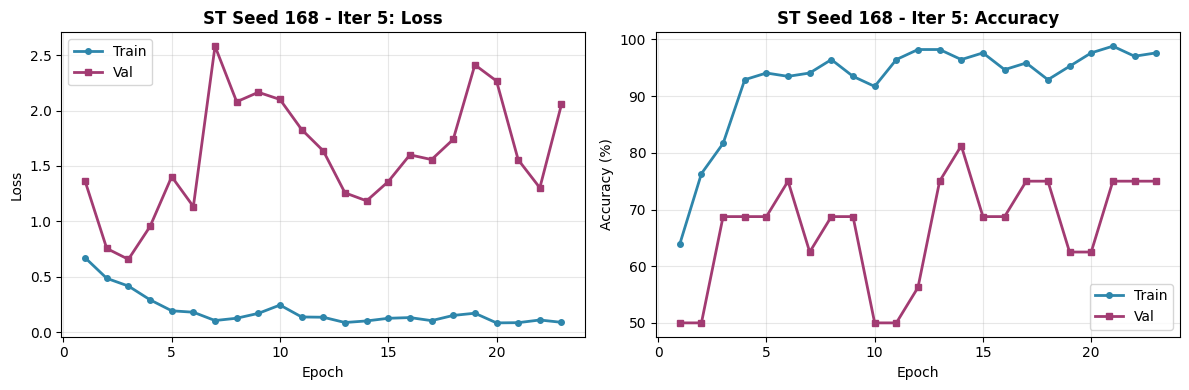

Evaluating Best Model (Seed 168)
Best Iteration: 5
Best Avg Acc: 79.69%
  Source: 84.38%
  Target: 75.00%
Loading model from: /root/autodl-tmp/models/ST_ADReSS_to_Lu_xlsr_t90/seed_168/st_iter_5.pth



Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
ADReSS (source domain)         84.38%      0.8485       87.50%       81.25%    0.4661
Lu (target domain)             75.00%      0.7500       75.00%       75.00%    1.2569
-------------------------------------------------------------------------------------

✓ Model verification passed (avg acc: 79.69%)


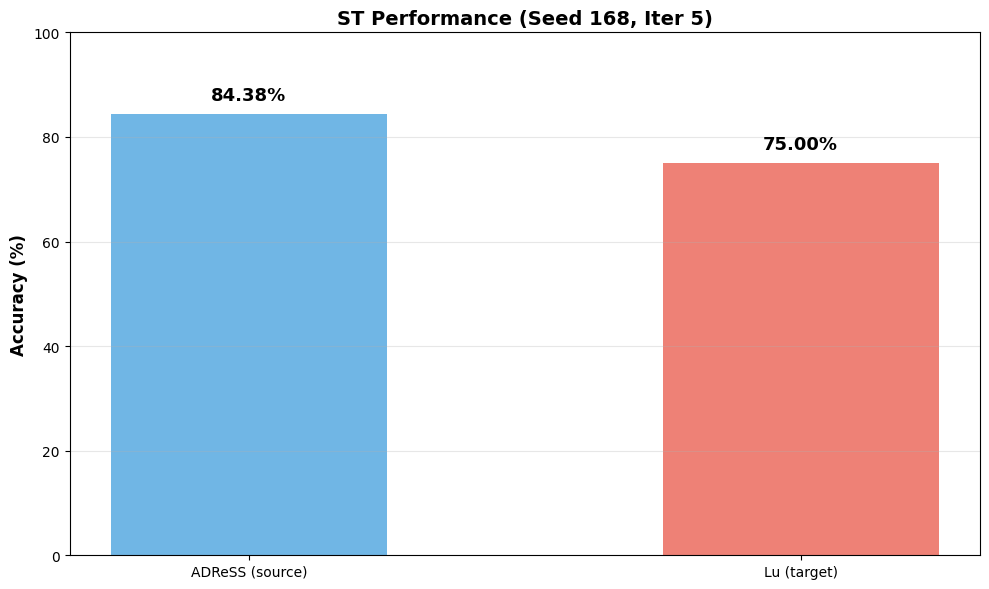

In [12]:
seed, all_metrics, all_histories, all_pseudo_stats = train_st(
    168, source_train_dataset, target_train_dataset, source_val_loader, target_val_loader,
    MODEL_OUTPUT_DIR, device, MAX_ITERATIONS, CONFIDENCE_THRESHOLD, MIN_PSEUDO_SAMPLES,
    CLASS_WEIGHT_CONTROL, CLASS_WEIGHT_DEMENTIA, ST_WARMUP_EPOCHS, ST_MAX_EPOCHS,
)
all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)

best_iter_idx = max(range(len(all_metrics)), key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0)
plot_training_curves(all_histories[best_iter_idx]['epochs'], all_histories[best_iter_idx]['train_losses'],
                     all_histories[best_iter_idx]['target_val_losses'], all_histories[best_iter_idx]['train_accs'],
                     all_histories[best_iter_idx]['target_val_accs'], title_prefix=f'ST Seed {seed} - Iter {best_iter_idx}')

source_metrics, target_metrics = evaluate_and_visualize_st(seed, all_metrics, all_histories, all_pseudo_stats,
                                                            source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

### Seed 336


Self-Training: Seed 336
Model Selection: Avg Acc (Source 0.5, Target 0.5)
Confidence Threshold: 0.9
Max Iterations: 5

Iteration 0: Initial training on source domain only

ST Iteration 0 - Training
Model Selection: Avg Acc (Source 0.5, Target 0.5)


Epoch   1 | Train: 0.589 | Source Val: 0.500 | Target Val: 0.500 | Avg: 0.500


Epoch   2 | Train: 0.710 | Source Val: 0.562 | Target Val: 0.500 | Avg: 0.531


Epoch   3 | Train: 0.839 | Source Val: 0.625 | Target Val: 0.438 | Avg: 0.531


Epoch   4 | Train: 0.903 | Source Val: 0.594 | Target Val: 0.375 | Avg: 0.484


...

Epoch  26 | Train: 0.994 | Source Val: 0.750 | Target Val: 0.750 | Avg: 0.750


Epoch  27 | Train: 0.994 | Source Val: 0.750 | Target Val: 0.625 | Avg: 0.688


Epoch  28 | Train: 0.989 | Source Val: 0.719 | Target Val: 0.625 | Avg: 0.672


Epoch  29 | Train: 0.989 | Source Val: 0.719 | Target Val: 0.688 | Avg: 0.703


Epoch  30 | Train: 0.971 | Source Val: 0.688 | Target Val: 0.688 | Avg: 0.688
Early stopping at epoch 30 (best epoch: 20)

Iteration 5 Best Results (Epoch 20):
  Avg Acc: 81.25%
  Source Acc: 81.25% | F1: 0.8125
  Target Acc: 81.25% | F1: 0.8235

Self-Training Summary (Seed 336)
Best iteration: 5
Best avg accuracy: 81.25%

Per-Iteration Results:
Iter   Avg Acc      Source Acc   Target Acc   Source F1    Target F1    Pseudo    
--------------------------------------------------------------------------------
0           76.56%      78.12%      75.00%     0.8000     0.7500        0
1           75.00%      75.00%      75.00%     0.7778     0.7778       41
2           76.56%      84.38%      68.75%     0.8387     0.6667       49
3           78.12%      81.25%      75.00%     0.8235     0.7778       38
4           79.69%      78.12%      81.25%     0.7586     0.8235       42
5           81.25%      81.25%      81.25%     0.8125     0.8235       50


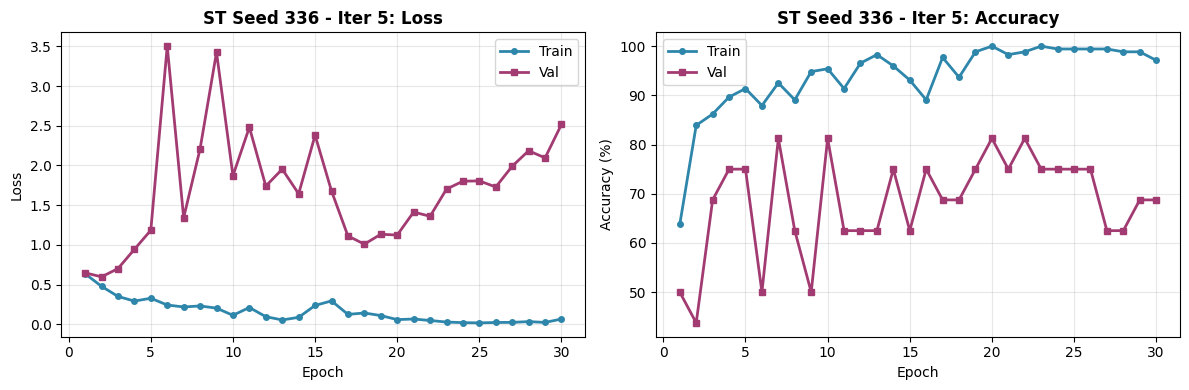

Evaluating Best Model (Seed 336)
Best Iteration: 5
Best Avg Acc: 81.25%
  Source: 81.25%
  Target: 81.25%
Loading model from: /root/autodl-tmp/models/ST_ADReSS_to_Lu_xlsr_t90/seed_336/st_iter_5.pth



Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
ADReSS (source domain)         81.25%      0.8125       81.25%       81.25%    0.5147
Lu (target domain)             81.25%      0.8235       87.50%       75.00%    1.1238
-------------------------------------------------------------------------------------

✓ Model verification passed (avg acc: 81.25%)


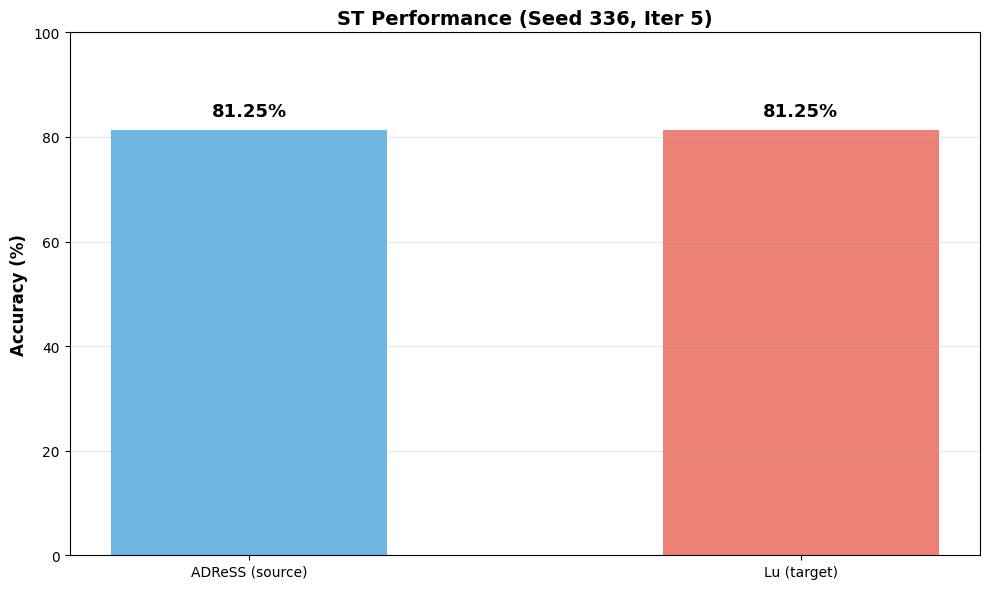

In [13]:
seed, all_metrics, all_histories, all_pseudo_stats = train_st(
    336, source_train_dataset, target_train_dataset, source_val_loader, target_val_loader,
    MODEL_OUTPUT_DIR, device, MAX_ITERATIONS, CONFIDENCE_THRESHOLD, MIN_PSEUDO_SAMPLES,
    CLASS_WEIGHT_CONTROL, CLASS_WEIGHT_DEMENTIA, ST_WARMUP_EPOCHS, ST_MAX_EPOCHS,
)
all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)

best_iter_idx = max(range(len(all_metrics)), key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0)
plot_training_curves(all_histories[best_iter_idx]['epochs'], all_histories[best_iter_idx]['train_losses'],
                     all_histories[best_iter_idx]['target_val_losses'], all_histories[best_iter_idx]['train_accs'],
                     all_histories[best_iter_idx]['target_val_accs'], title_prefix=f'ST Seed {seed} - Iter {best_iter_idx}')

source_metrics, target_metrics = evaluate_and_visualize_st(seed, all_metrics, all_histories, all_pseudo_stats,
                                                            source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

## 4 Summary and Visualization

In [14]:
seeds = all_results['seeds']

# Source domain results
source_accs = [m['acc'] * 100 for m in all_results['source_metrics']]
source_f1s = [m['f1'] for m in all_results['source_metrics']]
source_dementia_accs = [m['dementia_acc'] * 100 for m in all_results['source_metrics']]
source_control_accs = [m['control_acc'] * 100 for m in all_results['source_metrics']]
source_losses = [m['loss'] for m in all_results['source_metrics']]

# Target domain results
target_accs = [m['acc'] * 100 for m in all_results['target_metrics']]
target_f1s = [m['f1'] for m in all_results['target_metrics']]
target_dementia_accs = [m['dementia_acc'] * 100 for m in all_results['target_metrics']]
target_control_accs = [m['control_acc'] * 100 for m in all_results['target_metrics']]
target_losses = [m['loss'] for m in all_results['target_metrics']]

print(f"{'Dataset':<25} {'Mean Acc':<20} {'Mean F1':<20} {'Mean Loss':<15}")
print(f"{'-'*90}")
print(f"{f'{SOURCE_DATASET} (source domain)':<25} {np.mean(source_accs):>6.2f}% ± {np.std(source_accs):>4.2f}%  {np.mean(source_f1s):>8.4f} ± {np.std(source_f1s):>6.4f}  {np.mean(source_losses):>10.4f}")
print(f"{f'{TARGET_DATASET} (target domain)':<25} {np.mean(target_accs):>6.2f}% ± {np.std(target_accs):>4.2f}%  {np.mean(target_f1s):>8.4f} ± {np.std(target_f1s):>6.4f}  {np.mean(target_losses):>10.4f}")
print(f"{'-'*90}\n")

print(f"{'Seed':<8} {'Dataset':<25} {'Accuracy':<12} {'F1 Score':<12} {'Dementia':<12} {'Control':<12} {'Loss':<10}")
print(f"{'-'*90}")
for i, seed in enumerate(seeds):
    print(f"{seed:<8} {f'{SOURCE_DATASET} (source domain)':<25} {source_accs[i]:>10.2f}%  {source_f1s[i]:>10.4f}  {source_dementia_accs[i]:>10.2f}%  {source_control_accs[i]:>10.2f}%  {source_losses[i]:>8.4f}")
    print(f"{'':<8} {f'{TARGET_DATASET} (target domain)':<25} {target_accs[i]:>10.2f}%  {target_f1s[i]:>10.4f}  {target_dementia_accs[i]:>10.2f}%  {target_control_accs[i]:>10.2f}%  {target_losses[i]:>8.4f}")
    print(f"{'-'*90}")

Dataset                   Mean Acc             Mean F1              Mean Loss      
------------------------------------------------------------------------------------------
ADReSS (source domain)     81.25% ± 2.80%    0.8124 ± 0.0285      0.5602
Lu (target domain)         81.25% ± 3.95%    0.8144 ± 0.0405      1.0837
------------------------------------------------------------------------------------------

Seed     Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
------------------------------------------------------------------------------------------
21       ADReSS (source domain)         78.12%      0.7742       75.00%       81.25%    0.5688
         Lu (target domain)             87.50%      0.8750       87.50%       87.50%    0.7394
------------------------------------------------------------------------------------------
42       ADReSS (source domain)         78.12%      0.7879       81.25%       75.00%    0.6748
         Lu (target do

In [15]:
torch.cuda.empty_cache()